### importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib           
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [3]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\NVDA.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [4]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [5]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [6]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [7]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [8]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

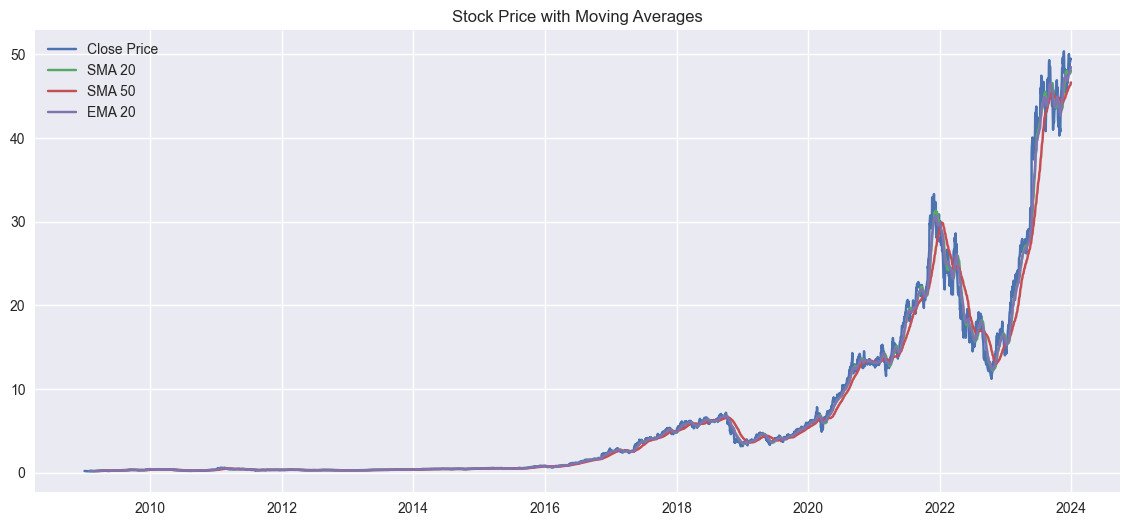

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

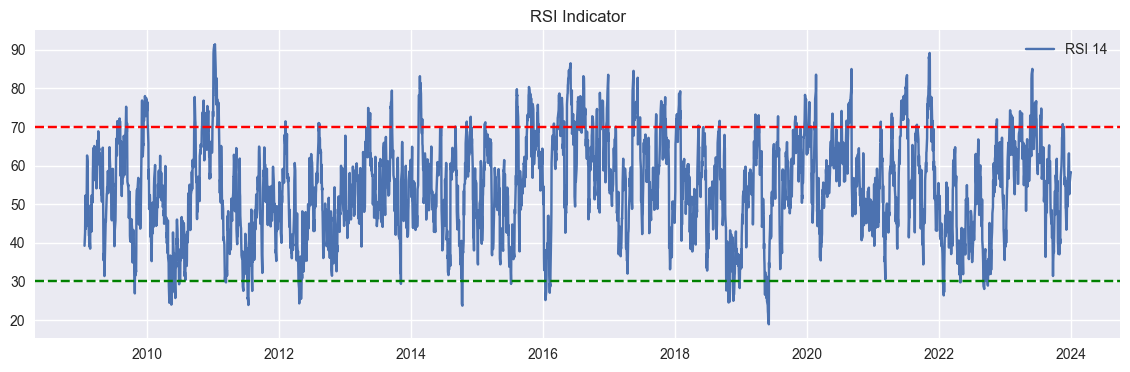

In [10]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

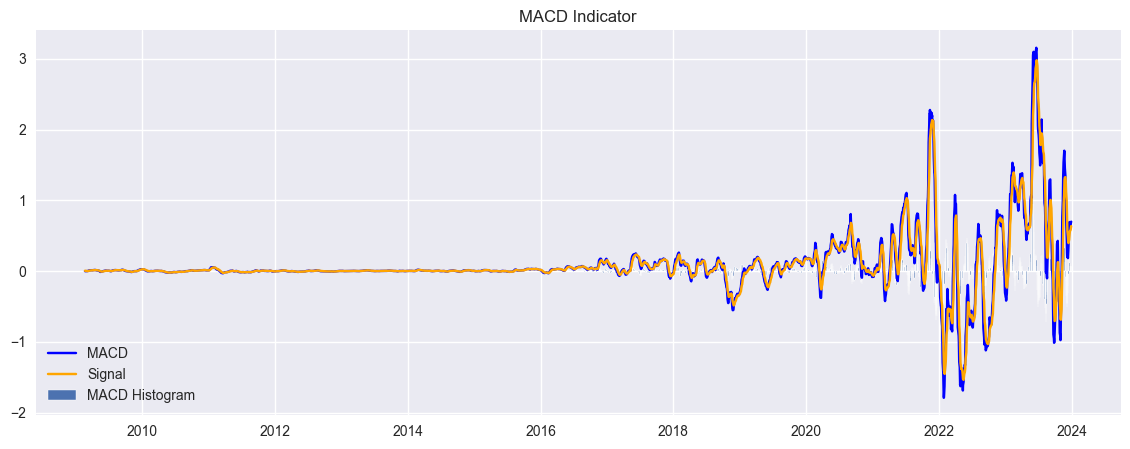

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

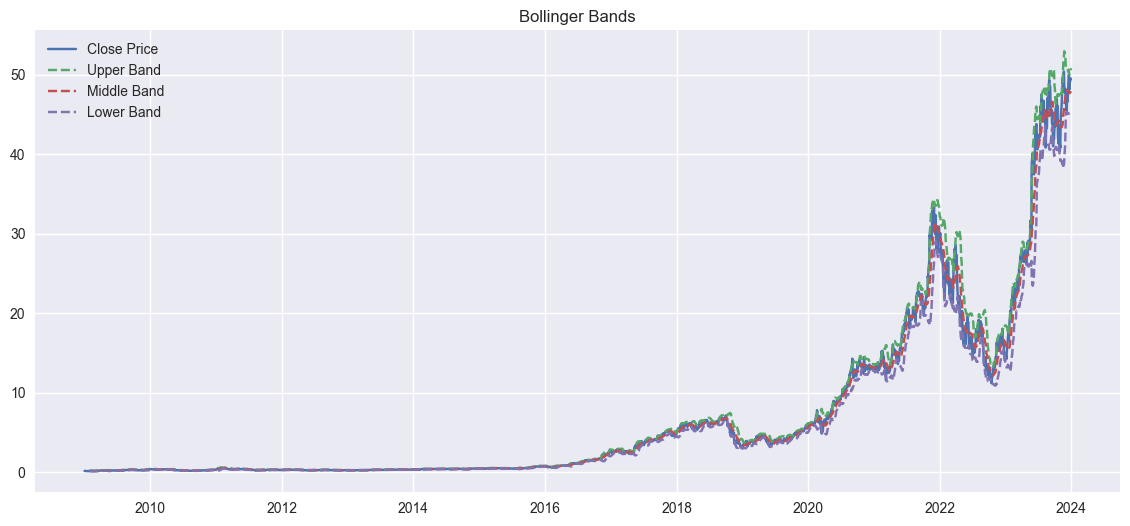

In [12]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std           min           25%  \
Close        3774.0  6.796822e+00  1.065975e+01  1.652686e-01  3.573966e-01   
High         3774.0  6.915713e+00  1.084353e+01  1.712284e-01  3.624222e-01   
Low          3774.0  6.666721e+00  1.046139e+01  1.622887e-01  3.517434e-01   
Open         3774.0  6.793541e+00  1.065914e+01  1.652686e-01  3.570170e-01   
Volume       3774.0  5.230753e+08  3.205760e+08  4.564400e+07  3.188510e+08   
SMA_20       3755.0  6.707341e+00  1.044679e+01  1.833656e-01  3.592328e-01   
SMA_50       3725.0  6.569826e+00  1.011850e+01  1.910377e-01  3.598546e-01   
EMA_20       3755.0  6.708080e+00  1.043732e+01  1.847066e-01  3.580823e-01   
RSI_14       3760.0  5.452072e+01  1.248934e+01  1.889075e+01  4.560961e+01   
MACD         3741.0  8.881521e-02  4.453874e-01 -1.790507e+00 -4.459059e-03   
MACD_signal  3741.0  8.814200e-02  4.216559e-01 -1.536606e+00 -3.648898e-03   
MACD_hist    3741.0  6.732107e-04  1.273211e-01 -7.2

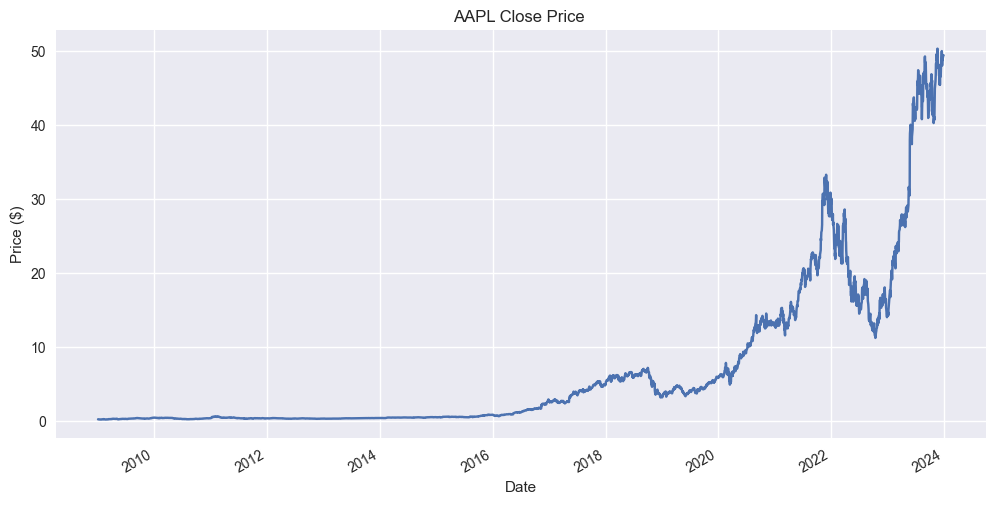

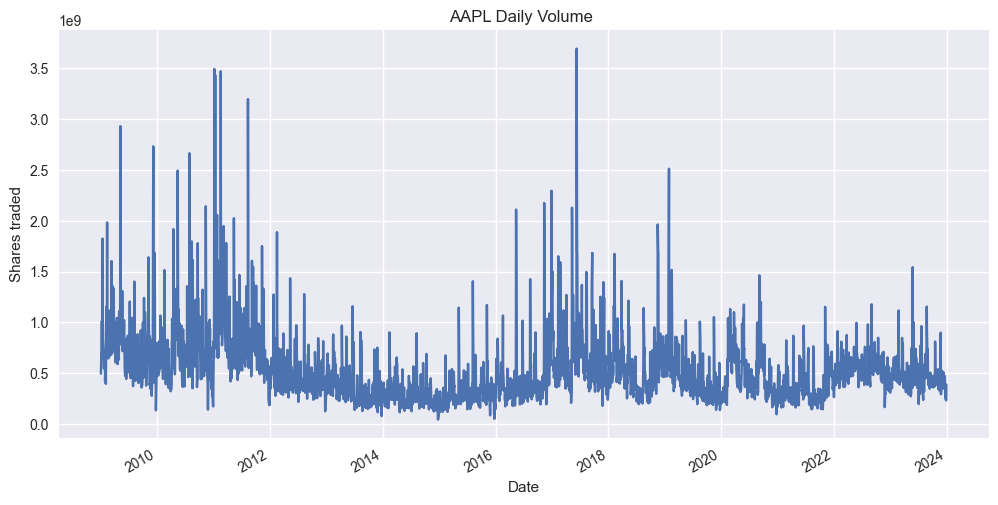

In [13]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [14]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,47.706983,46.257777,48.024644,55.352119,0.634352,0.564438,0.069914,50.152737,47.706983,45.261229
2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,47.759019,46.334178,48.141754,57.245971,0.655689,0.582688,0.073001,50.288523,47.759019,45.229515
2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,47.838989,46.400666,48.260847,57.837928,0.675937,0.601338,0.074599,50.466927,47.838989,45.211051
2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,47.908266,46.512367,48.378593,58.310919,0.692470,0.619564,0.072906,50.632585,47.908266,45.183947
2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,48.046003,46.658888,48.485126,58.310919,0.697532,0.635158,0.062374,50.799025,48.046003,45.292980


### Price + SMA + Bollinger Bands

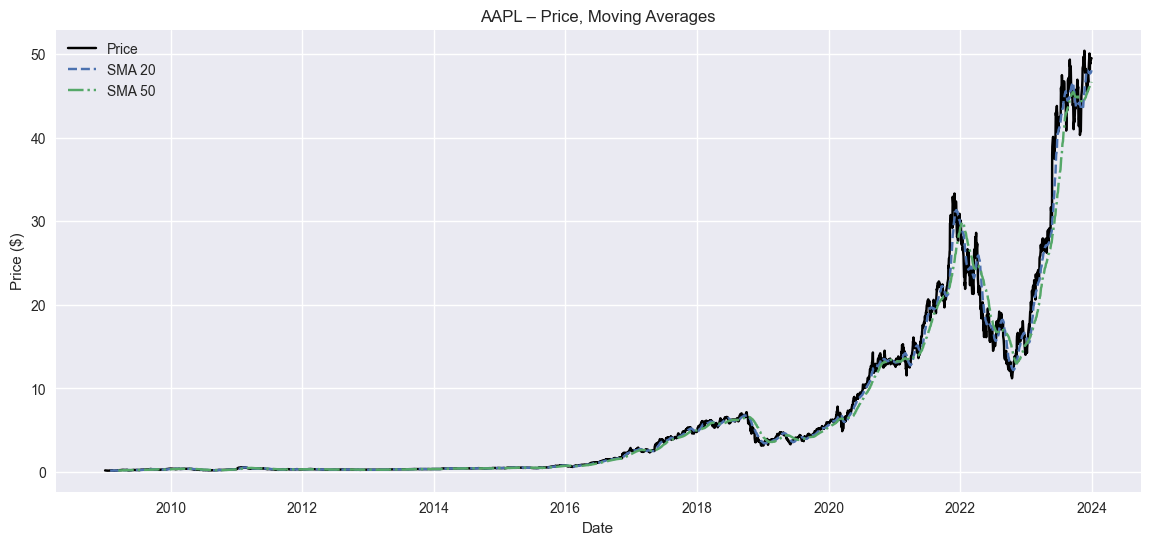

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

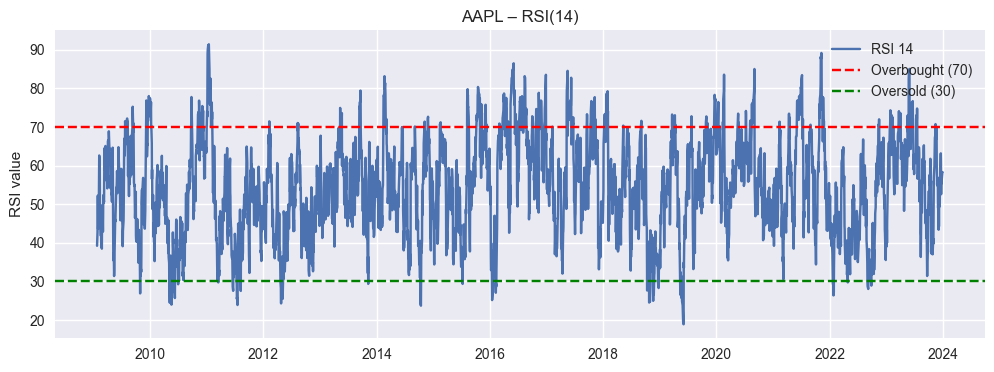

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

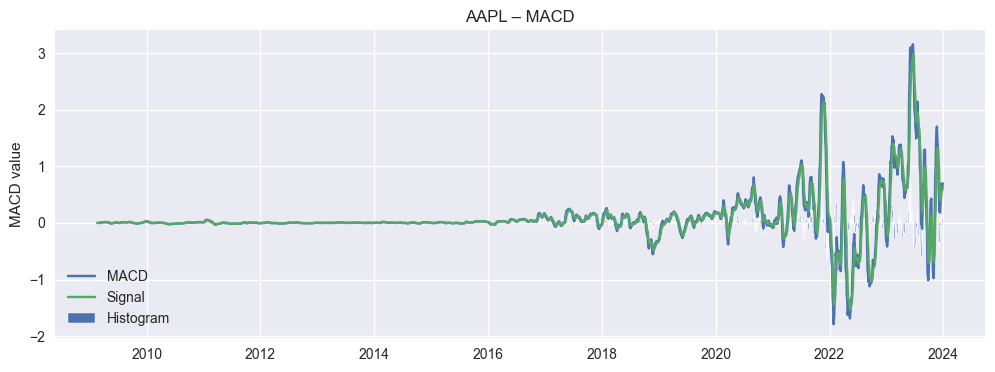

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
